In [1]:
!pip install pillow

from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving download.jpg to download.jpg


Format: JPEG
Mode: RGB
Size: (735, 981)


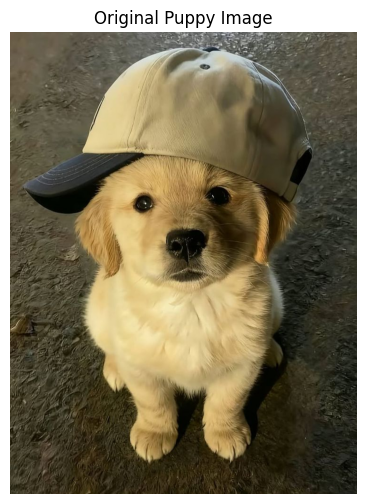

In [3]:
# Load the puppy image
image_colored = Image.open("download.jpg")

# Print basic info
print("Format:", image_colored.format)
print("Mode:", image_colored.mode)
print("Size:", image_colored.size)

# Display the image using matplotlib
plt.figure(figsize=(6, 6))
plt.imshow(image_colored)
plt.title("Original Puppy Image")
plt.axis("off")
plt.show()

Full image shape: (981, 735, 3)
Cropped shape: (100, 100, 3)


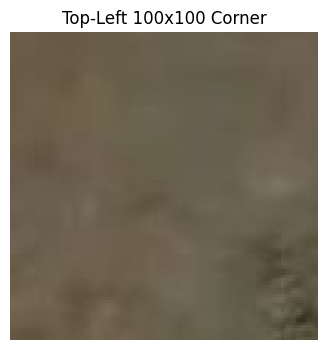

In [4]:
# Convert image to numpy array first
image_array = np.array(image_colored)
print("Full image shape:", image_array.shape)

# Extract top-left 100x100 pixels using array slicing
top_left = image_array[:100, :100, :]
print("Cropped shape:", top_left.shape)

# Display the cropped section
plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title("Top-Left 100x100 Corner")
plt.axis("off")
plt.show()

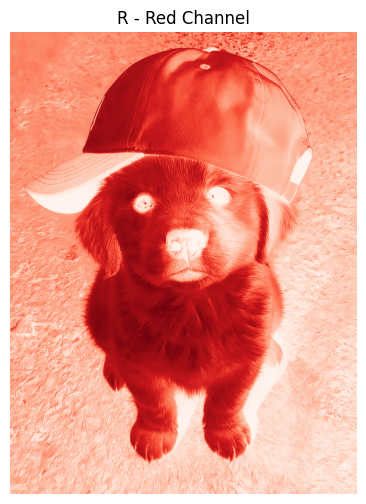

In [6]:
# Extract and display Red channel
red_channel = image_array[:, :, 0]

plt.figure(figsize=(6, 6))
plt.imshow(red_channel, cmap="Reds")
plt.title("R - Red Channel")
plt.axis("off")
plt.show()

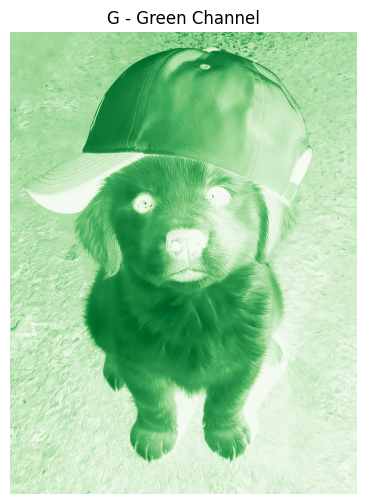

In [7]:
# Extract and display Green channel
green_channel = image_array[:, :, 1]

plt.figure(figsize=(6, 6))
plt.imshow(green_channel, cmap="Greens")
plt.title("G - Green Channel")
plt.axis("off")
plt.show()

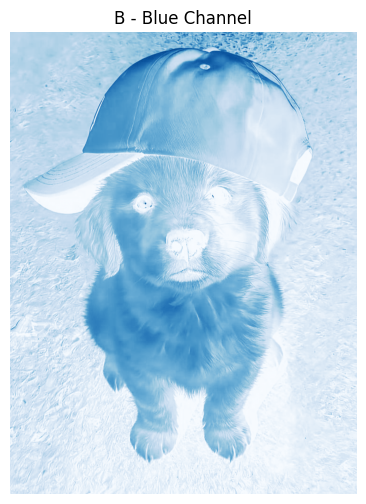

In [8]:
# Extract and display Blue channel
blue_channel = image_array[:, :, 2]

plt.figure(figsize=(6, 6))
plt.imshow(blue_channel, cmap="Blues")
plt.title("B - Blue Channel")
plt.axis("off")
plt.show()

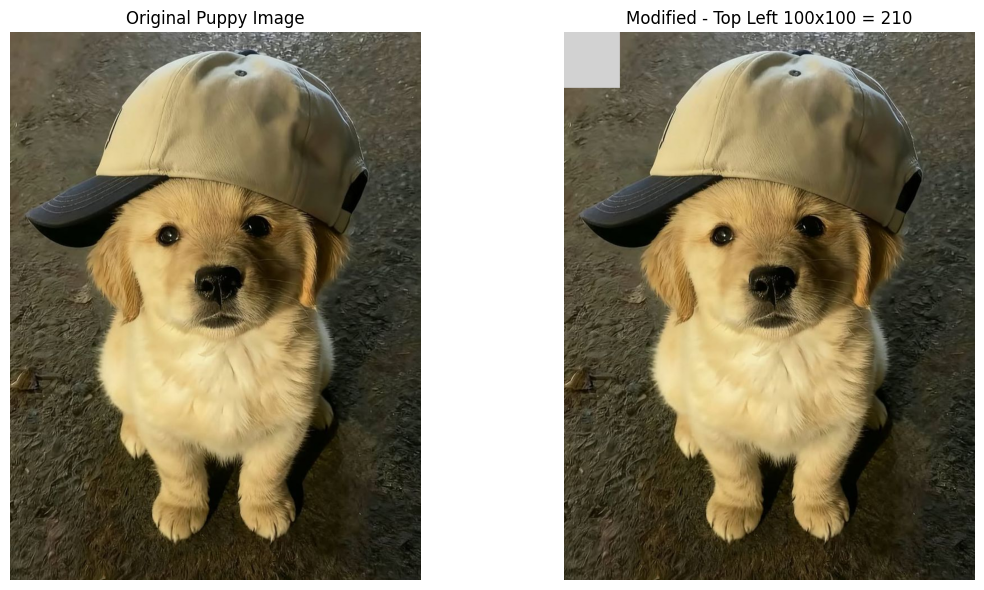

In [9]:
# Make a copy so we don't change the original image
image_modified = image_array.copy()

# Set top-left 100x100 pixels to 210 (light gray)
image_modified[:100, :100, :] = 210

# Display original and modified side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(image_array)
axes[0].set_title("Original Puppy Image")
axes[0].axis("off")

axes[1].imshow(image_modified)
axes[1].set_title("Modified - Top Left 100x100 = 210")
axes[1].axis("off")

plt.tight_layout()
plt.show()

Grayscale image shape: (981, 735)


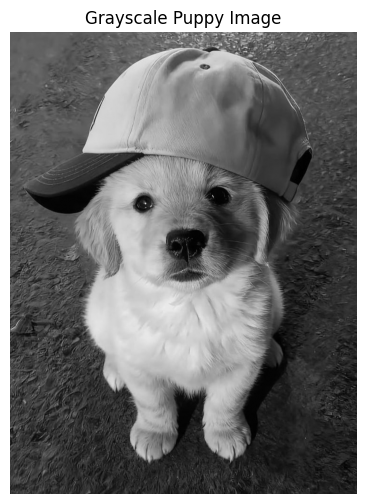

In [10]:
# Convert the colored image to grayscale
image_gray = image_colored.convert("L")

# Convert to numpy array
image_array_gray = np.array(image_gray)
print("Grayscale image shape:", image_array_gray.shape)

# Display the grayscale image
plt.figure(figsize=(6, 6))
plt.imshow(image_array_gray, cmap="gray")
plt.title("Grayscale Puppy Image")
plt.axis("off")
plt.show()

Middle section shape: (150, 150)


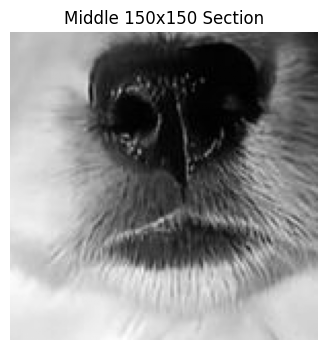

In [11]:
# Find the center of the image
center_row = image_array_gray.shape[0] // 2
center_col = image_array_gray.shape[1] // 2

# Extract 150px section from center
middle_section = image_array_gray[center_row-75:center_row+75,
                                   center_col-75:center_col+75]

print("Middle section shape:", middle_section.shape)

# Display
plt.figure(figsize=(4, 4))
plt.imshow(middle_section, cmap="gray")
plt.title("Middle 150x150 Section")
plt.axis("off")
plt.show()

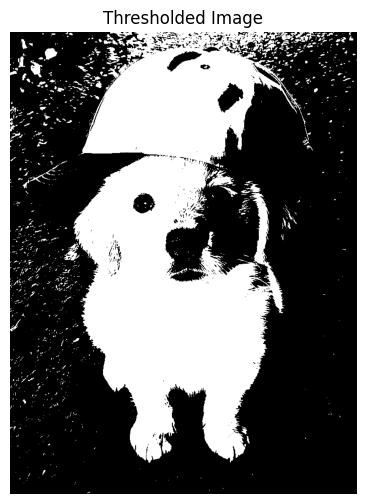

In [12]:
# Copy the grayscale array
image_threshold = image_array_gray.copy()

# Set pixels below 100 to 0, above 100 to 255
image_threshold[image_threshold < 100] = 0
image_threshold[image_threshold >= 100] = 255

plt.figure(figsize=(6, 6))
plt.imshow(image_threshold, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")
plt.show()

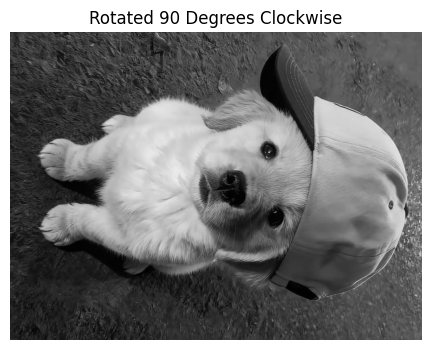

In [13]:
# Rotate 90 degrees clockwise (-90 in PIL)
image_rotated = image_gray.rotate(-90, expand=True)

plt.figure(figsize=(8, 4))
plt.imshow(image_rotated, cmap="gray")
plt.title("Rotated 90 Degrees Clockwise")
plt.axis("off")
plt.show()

RGB shape: (981, 735, 3)


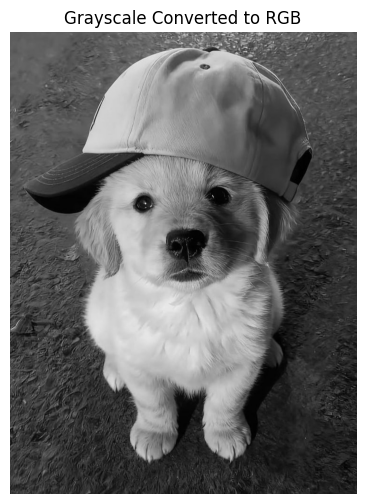

In [14]:
# Stack grayscale across 3 channels to make RGB
image_rgb = np.stack([image_array_gray,
                       image_array_gray,
                       image_array_gray], axis=2)

print("RGB shape:", image_rgb.shape)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

In [15]:
# Use our grayscale array
# Step 1: Convert to float for calculations
image_float = image_array_gray.astype(float)
print("Image shape:", image_float.shape)

# Step 2: Center the data (subtract mean of each column)
mean = np.mean(image_float, axis=0)
image_centered = image_float - mean
print("Mean shape:", mean.shape)
print("Centered image shape:", image_centered.shape)

Image shape: (981, 735)
Mean shape: (735,)
Centered image shape: (981, 735)


In [16]:
# Calculate covariance matrix
# Divide by (n-1) for unbiased estimate
n = image_centered.shape[0]
covariance_matrix = np.dot(image_centered.T, image_centered) / (n - 1)
print("Covariance matrix shape:", covariance_matrix.shape)

Covariance matrix shape: (735, 735)


In [17]:
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)

# Sort in descending order (eigh returns ascending)
sorted_index = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_index]
eigenvectors = eigenvectors[:, sorted_index]

print("Number of eigenvalues:", len(eigenvalues))
print("Top 5 eigenvalues:", eigenvalues[:5])

Number of eigenvalues: 735
Top 5 eigenvalues: [741522.67208037 234395.8218151  130527.11668741  91176.68978293
  62443.82979615]


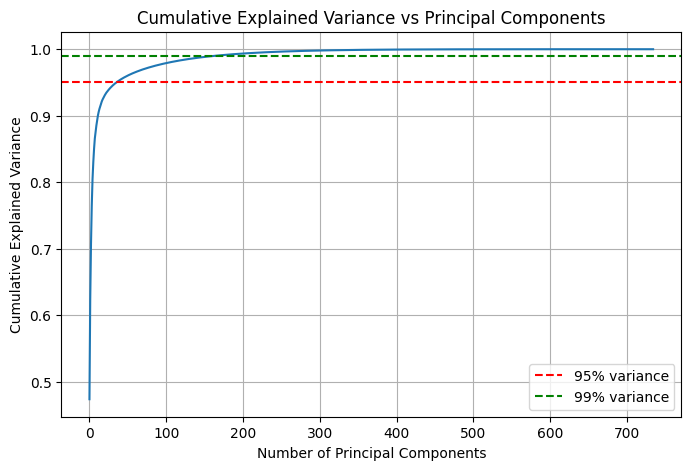

In [18]:
# Calculate explained variance ratio
total_variance = np.sum(eigenvalues)
explained_variance = eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.figure(figsize=(8, 5))
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance vs Principal Components")
plt.axhline(y=0.95, color='r', linestyle='--', label="95% variance")
plt.axhline(y=0.99, color='g', linestyle='--', label="99% variance")
plt.legend()
plt.grid(True)
plt.show()

In [20]:
def reconstruct_image(image_centered, eigenvectors, k, mean, shape):
    """
    Reconstructs image using top k principal components.

    Parameters:
        image_centered: centered image array
        eigenvectors: sorted eigenvectors
        k (int): number of principal components to use
        mean: mean of original image
        shape: original image shape
    Returns:
        numpy array: reconstructed image
    """
    # Select top k eigenvectors
    top_k = eigenvectors[:, :k]

    # Project data onto k components
    projected = np.dot(image_centered, top_k)

    # Reconstruct back to original space
    reconstructed = np.dot(projected, top_k.T) + mean

    # Clip values to valid pixel range
    reconstructed = np.clip(reconstructed, 0, 255)

    return reconstructed.astype(np.uint8)

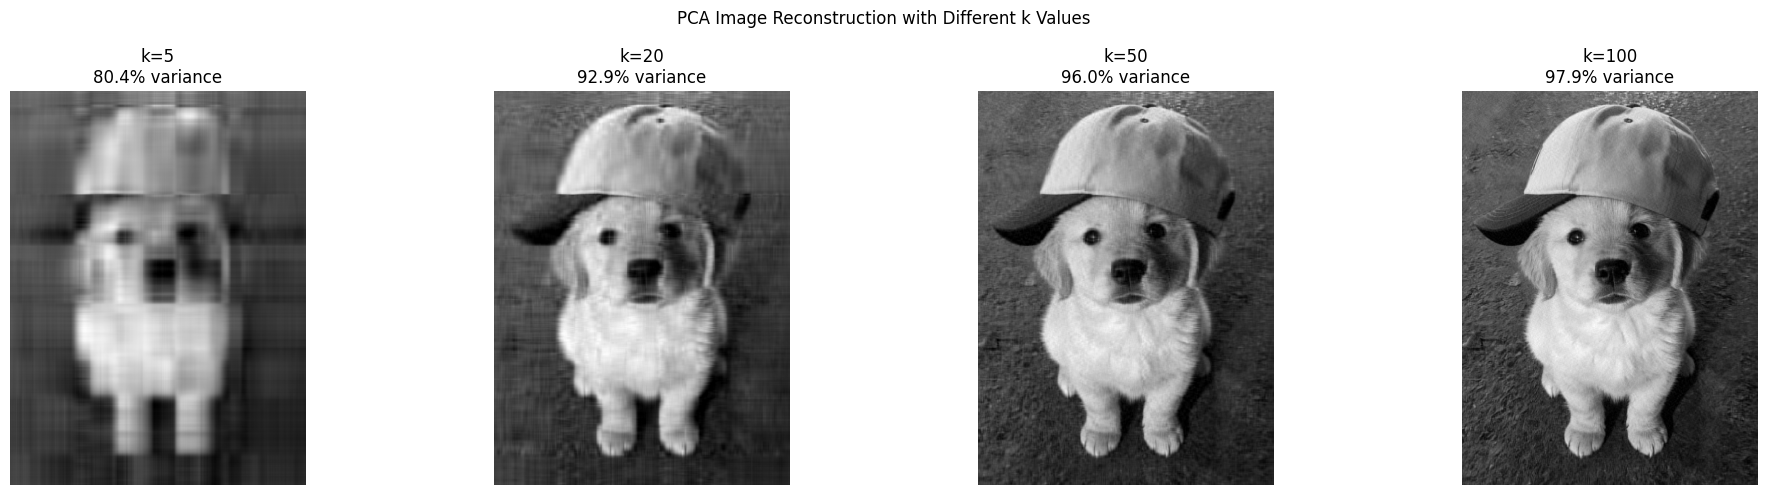

In [21]:
# Try 4 different numbers of components
k_values = [5, 20, 50, 100]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, k in enumerate(k_values):
    # Reconstruct with k components
    reconstructed = reconstruct_image(
        image_centered, eigenvectors, k, mean, image_float.shape
    )

    # Calculate variance explained
    variance_explained = cumulative_variance[k-1] * 100

    axes[i].imshow(reconstructed, cmap="gray")
    axes[i].set_title(f"k={k}\n{variance_explained:.1f}% variance")
    axes[i].axis("off")

plt.suptitle("PCA Image Reconstruction with Different k Values")
plt.tight_layout()
plt.show()